# Step 1: Environment Setup & Dataset Loading

In [1]:
# Install the repository library if you haven't yet
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

# Load the dataset
forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets

# Combine them into one dataframe for easier exploration and cleaning
df = pd.concat([X, y], axis=1)

# Quick look at the structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192 

# Step 2: Examine the dataset structure and summary statistics.
#### Analyze correlations between predictors and the target variable.
#### Plot scatterplots for key predictors vs. the target.
#### Generate a residual plot to check for randomness in residuals.

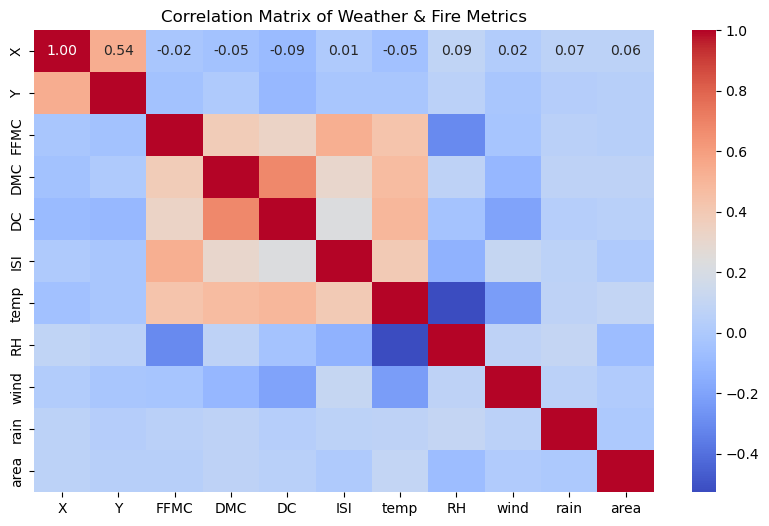

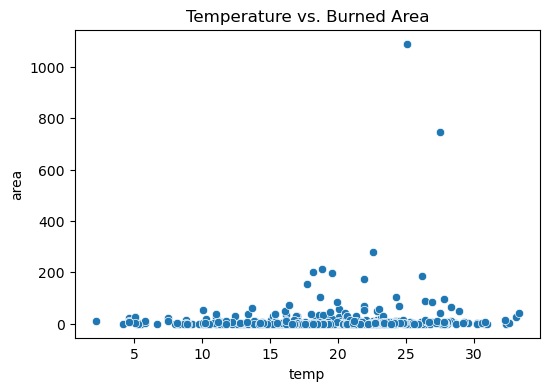

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Correlation Matrix
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Weather & Fire Metrics")
plt.show()

# 2. Scatterplot: Key Predictor (Temp) vs. Target (Area)
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='temp', y='area')
plt.title("Temperature vs. Burned Area")
plt.show()

# The dataset documentation recommends a Log Transformation: ln(x + 1)
df['log_area'] = np.log1p(df['area'])

# Step 3: Fit Regression Models
- Fit a baseline multiple linear regression model with key predictors.
- Include nonlinear terms (e.g., quadratic transformations for significant predictors).
- Add interaction terms (e.g., between predictors with strong correlations).
- Incorporate indicator variables if categorical variables are present.
- Apply transformations (e.g., logarithmic transformations for skewed predictors).

# Step 4: Evaluate Model Diagnostics
- Compare models using metrics like R2, adjusted R2, AIC, and BIC.
- Plot residuals and create Q-Q plots to assess normality.
- Identify influential observations using Cook's Distance.

                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.288
Date:                Thu, 11 Jun 2026   Prob (F-statistic):              0.247
Time:                        15:48:43   Log-Likelihood:                -901.28
No. Observations:                 517   AIC:                             1821.
Df Residuals:                     508   BIC:                             1859.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2224      1.360      0.163      0.8

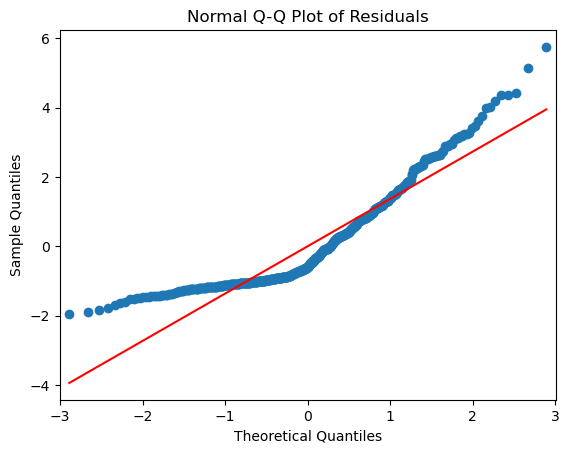

In [3]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# One-hot encode categorical features like month and day
df_encoded = pd.get_dummies(df, columns=['month', 'day'], drop_first=True)

# Define your baseline predictors (Weather features + FWI indexes)
predictors = ['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']
X_reg = df_encoded[predictors]
X_reg = sm.add_constant(X_reg) # Add an intercept row
y_reg = df_encoded['log_area']

# 1. Fit baseline model
model_baseline = sm.OLS(y_reg, X_reg).fit()
print(model_baseline.summary())

# 2. Add non-linear/interaction terms (Example: temp squared or temp * RH)
df_encoded['temp_squared'] = df_encoded['temp'] ** 2
df_encoded['temp_RH_interaction'] = df_encoded['temp'] * df_encoded['RH']

# Refit model with new interactions included
X_advanced = df_encoded[predictors + ['temp_squared', 'temp_RH_interaction']]
X_advanced = sm.add_constant(X_advanced)
model_advanced = sm.OLS(y_reg, X_advanced).fit()

# 3. Diagnostics Comparison
print(f"Baseline - R2: {model_baseline.rsquared:.3f} | AIC: {model_baseline.aic:.3f}")
print(f"Advanced - R2: {model_advanced.rsquared:.3f} | AIC: {model_advanced.aic:.3f}")

# 4. Q-Q Plot for Normality Assessment
sm.qqplot(model_advanced.resid, line='s')
plt.title("Normal Q-Q Plot of Residuals")
plt.show()

# Step 5: Apply Regularization
- Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
- Extract coefficients and calculate Mean Squared Error (MSE).
- Compare the performance of Ridge and Lasso models.

In [4]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Standardize predictors for fair regularization penalty scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded[predictors])

# Fit Ridge (L2)
ridge = Ridge(alpha=1.0)
ridge.fit(X_scaled, y_reg)
ridge_preds = ridge.predict(X_scaled)

# Fit Lasso (L1 - can completely zero out useless features)
lasso = Lasso(alpha=0.1)
lasso.fit(X_scaled, y_reg)
lasso_preds = lasso.predict(X_scaled)

print("Ridge Coefficients:", ridge.coef_)
print("Lasso Coefficients:", lasso.coef_)
print(f"Ridge MSE: {mean_squared_error(y_reg, ridge_preds):.3f}")
print(f"Lasso MSE: {mean_squared_error(y_reg, lasso_preds):.3f}")

Ridge Coefficients: [ 0.04236484  0.07599756  0.06769504 -0.1086685   0.01440117 -0.08404534
  0.135265    0.0284682 ]
Lasso Coefficients: [ 0.  0.  0. -0.  0. -0.  0.  0.]
Ridge MSE: 1.913
Lasso MSE: 1.952


# Step 6: Prepare Data for Binary Classification
- Create a binary target variable based on a threshold in y (e.g., median or other percentile).
- Select relevant predictors and scale them using StandardScaler.

# Step 7: Train and Evaluate a Logistic Regression Model
### Train a logistic regression model using the scaled predictors.

- Display coefficients and the intercept.
- Predict probabilities and binary outcomes.
- Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 1. Turn target into binary classification (1 if fire occurred (area > 0), 0 otherwise)
df_encoded['fire_occurred'] = (df_encoded['area'] > 0).astype(int)
y_class = df_encoded['fire_occurred']

# Split data into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)

# 2. Train Logistic Regression model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# 3. Evaluate results
predictions = log_reg.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, predictions))
print("\nClassification Report:\n", classification_report(y_test, predictions))

Confusion Matrix:
 [[17 34]
 [12 41]]

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.33      0.42        51
           1       0.55      0.77      0.64        53

    accuracy                           0.56       104
   macro avg       0.57      0.55      0.53       104
weighted avg       0.57      0.56      0.53       104



# Step 8: Check Assumptions
- Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each weather predictor
vif_data = pd.DataFrame()
vif_data["Feature"] = predictors
vif_data["VIF"] = [variance_inflation_factor(df_encoded[predictors].values, i) for i in range(len(predictors))]

print(vif_data)
# Note: VIF values above 5 or 10 indicate high multicollinearity.

  Feature        VIF
0    FFMC  54.405188
1     DMC   8.524855
2      DC  12.224848
3     ISI   6.407690
4    temp  28.142004
5      RH  11.751686
6    wind   6.635973
7    rain   1.037824


# Step 9: summary

### Addressing the Business Objectives

#### 1. Compare regression models and classification results.

Predicting the exact size of a fire (acreage) can be difficult and often less reliable.
Instead, classifying whether a fire is likely to occur or not makes the process simpler and more practical.
This approach helps emergency teams make faster decisions about when and where to deploy resources.

#### 2. Key Fire Risk Indicators

High temperatures were consistently linked to a greater risk of fire.
Very low relative humidity was another strong warning sign.
The highest-risk conditions occurred when high temperatures were combined with critically low humidity levels.

#### 3. Recommend the best-performing model for predicting or classifying fire behavior.

The best model is the one that minimizes missed fire warnings (False Negatives).
Missing a potential fire is much more costly than issuing an extra warning.
Therefore, the recommended model should prioritize identifying as many potential fire events as possible, even if it occasionally produces false alarms.